**Struttura:**
- Sezione 0 — Definizioni
- Sezione 1 — Modelli PyTorch batch + ottimizzatore multistart
- Sezione 2 — MOESM2: Nd-LSCO (fit globali gradino + Bessel)
- Sezione 3 — MOESM4: LSCO S1 (fit globali)
- Sezione 4 — Fit Nd-LSCO con calibrazione A153 (Bessel)
- Sezione 5 — Fit scalino m* fissata

**Strategia multistart:**
- *Gradino*: grid sweep su GPU (PyTorch, N_grid=30k) → top-30 con L-BFGS-B + gradiente autograd.
- *Bessel*: grid sweep CPU + raffinamento parallelo joblib (n_jobs=-1 = tutti i core).
- I fit indipendenti per-T restano su Fit_Ataei.ipynb.

## Definizioni

In [12]:
# --- T-dipendenza switchable ---
T_DEP = {
    "G1":   "quadratic",
    "G2":   "quadratic",
    "G_is": "linear",
    "G_an": "linear",
}

In [13]:
import importlib
import warnings

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from joblib import Parallel, delayed
from scipy.optimize import minimize
from tqdm.notebook import tqdm

import chambers_lib as cl
import vik_lib

importlib.reload(cl)
importlib.reload(vik_lib)
from vik_lib import font1, font2
from chambers_lib import (
    build_global_residual, eval_T_dep, fit_phi_tanh,
    fit_T_dep, log_bin, phi_tanh,
)

eval_phi_tanh = phi_tanh


def _a_cap(style, max_G, c_max, T_high):
    power = 2 if style == 'quadratic' else 1
    return max((max_G - c_max), 1e-6) / T_high**power


def _p0_a(style, target, c_guess, T_high):
    power = 2 if style == 'quadratic' else 1
    return max((target - c_guess), 0.0) / T_high**power


%matplotlib inline
print("chambers_lib caricato.  K_meV =", cl.K_MEV)

Funzioni definite.
chambers_lib caricato.  K_meV = 0.116


# Modelli PyTorch e Ottimizzatore Multistart

## Setup dispositivo

In [14]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

_K_MEV = torch.tensor(cl.K_MEV, dtype=torch.float64)  # hbar*omega_c

Device: cuda
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU
  VRAM: 8.5 GB


## Modello gradino — batch PyTorch

In [15]:
def _sigma_xx_step_batch(B, G1, G2, phi_star, m_star):
    """
    B             : (N_B,)      float64
    G1,G2,phi_star,m_star : (N,) float64
    Returns       : (N, N_B)    float64  sigma_xx reale
    """
    dev  = B.device
    K    = _K_MEV.to(dev)
    Bc   = B.to(torch.cdouble).unsqueeze(0)           # (1, N_B)
    G1c  = G1.to(torch.cdouble).unsqueeze(1)          # (N, 1)
    G2c  = G2.to(torch.cdouble).unsqueeze(1)
    phc  = phi_star.to(torch.cdouble).unsqueeze(1)
    msc  = m_star.to(torch.cdouble).unsqueeze(1)

    psi_c = torch.pi / 4 - phc
    w     = K * Bc / msc                              # (N, N_B)
    w     = torch.where(
        w.abs() < 1e-14,
        torch.tensor(1e-14+0j, dtype=torch.cdouble, device=dev),
        w,
    )

    S1 = 2 * psi_c / w
    S2 = 2 * phc   / w

    denom  = 1 + 1j * torch.exp(-(G1c * S2 + G2c * S1))
    eG2_S1 = torch.exp(-(G2c + 1j * w) * S1)
    eG1_S2 = torch.exp(-(G1c + 1j * w) * S2)

    Z12 = (1 - eG2_S1) / denom * (1 / (G2c + 1j*w) - 1 / (G1c + 1j*w))
    Z21 = (1 - eG1_S2) / denom * (1 / (G1c + 1j*w) - 1 / (G2c + 1j*w))
    t1  = (1 - eG1_S2) * 0.5
    t2  = (1 - eG2_S1) * 0.5

    O_I1 = (4 / (G1c**2 + w**2)) * (G1c - 1j*w) * (phc   + Z12 * w * t1)
    O_I2 = (4 / (G2c**2 + w**2)) * (G2c - 1j*w) * (psi_c + Z21 * w * t2)

    return torch.conj(O_I1 + O_I2).real              # (N, N_B)


def mr_step_batch(B, G1, G2, phi_star, m_star):
    """MR = sigma_0/sigma_xx - 1, batch su N starts."""
    B0    = torch.tensor([1e-8], dtype=torch.float64, device=B.device)
    sig0  = _sigma_xx_step_batch(B0, G1, G2, phi_star, m_star)  # (N, 1)
    sig_B = _sigma_xx_step_batch(B,  G1, G2, phi_star, m_star)  # (N, N_B)
    return sig0 / sig_B - 1.0

## Helper T-dep batch

In [16]:
def eval_T_dep_batch(T_val, a, c, style):
    """a, c: (N,) tensors; T_val: float. Returns (N,)."""
    if style == 'linear':    return a * T_val + c
    if style == 'quadratic': return a * T_val**2 + c
    raise ValueError(style)


def phi_tanh_batch(T_val, phi0, dphi, T_phi):
    """phi*(T) = phi0 + dphi*tanh(T/T_phi). Tensors (N,) -> (N,)."""
    return phi0 + dphi * torch.tanh(
        torch.tensor(T_val, dtype=torch.float64, device=phi0.device) / T_phi
    )

## Factory loss batch — gradino

8 params: `[a1, c1, a2, c2, phi0, dphi, T_phi, m_star]`

In [17]:
def build_loss_step_batch(DATA, B_MIN, T_LIST, T_DEP, device, n_bins=60):
    """Loss(params (N,8)) -> (N,). Completamente differenziabile via autograd."""
    data_T = {}
    for T in T_LIST:
        B, R = DATA[T]
        sel  = np.isfinite(B) & np.isfinite(R) & (B > B_MIN[T])
        Bs, Rs = log_bin(B[sel], R[sel], n_bins)
        data_T[T] = (
            torch.tensor(Bs, dtype=torch.float64, device=device),
            torch.tensor(Rs, dtype=torch.float64, device=device),
        )

    def loss_fn(params):
        a1, c1 = params[:, 0], params[:, 1]
        a2, c2 = params[:, 2], params[:, 3]
        phi0, dphi, T_phi, ms = params[:, 4], params[:, 5], params[:, 6], params[:, 7]
        total = torch.zeros(params.shape[0], dtype=torch.float64, device=device)
        for T in T_LIST:
            Bt, Rt = data_T[T]
            G1 = eval_T_dep_batch(float(T), a1, c1, T_DEP['G1'])
            G2 = eval_T_dep_batch(float(T), a2, c2, T_DEP['G2'])
            ph = phi_tanh_batch(float(T), phi0, dphi, T_phi)
            ph = ph.clamp(1e-6, float(cl.PHI_MAX))
            R_mod = 1.0 + mr_step_batch(Bt, G1, G2, ph, ms)
            res   = R_mod - Rt.unsqueeze(0)
            total += (res**2).mean(dim=1)
        return total

    return loss_fn


def build_loss_step_batch_mfixed(DATA, B_MIN, T_LIST, T_DEP, M_STAR, device, n_bins=60):
    """Come sopra ma m* fissata. 7 params: [a1,c1,a2,c2,phi0,dphi,T_phi]."""
    data_T = {}
    for T in T_LIST:
        B, R = DATA[T]
        sel  = np.isfinite(B) & np.isfinite(R) & (B > B_MIN[T])
        Bs, Rs = log_bin(B[sel], R[sel], n_bins)
        data_T[T] = (
            torch.tensor(Bs, dtype=torch.float64, device=device),
            torch.tensor(Rs, dtype=torch.float64, device=device),
        )
    ms_t = torch.tensor(M_STAR, dtype=torch.float64, device=device)

    def loss_fn(params):
        a1, c1 = params[:, 0], params[:, 1]
        a2, c2 = params[:, 2], params[:, 3]
        phi0, dphi, T_phi = params[:, 4], params[:, 5], params[:, 6]
        ms    = ms_t.expand(params.shape[0])
        total = torch.zeros(params.shape[0], dtype=torch.float64, device=device)
        for T in T_LIST:
            Bt, Rt = data_T[T]
            G1 = eval_T_dep_batch(float(T), a1, c1, T_DEP['G1'])
            G2 = eval_T_dep_batch(float(T), a2, c2, T_DEP['G2'])
            ph = phi_tanh_batch(float(T), phi0, dphi, T_phi)
            ph = ph.clamp(1e-6, float(cl.PHI_MAX))
            R_mod = 1.0 + mr_step_batch(Bt, G1, G2, ph, ms)
            res   = R_mod - Rt.unsqueeze(0)
            total += (res**2).mean(dim=1)
        return total

    return loss_fn

## Factory loss numpy — Bessel

`MR_Bessel` usa `scipy.special.iv` (non portabile su GPU): la parallelizzazione avviene via joblib su tutti i core CPU.

In [18]:
def build_loss_bessel_np(DATA, B_MIN, T_LIST, unpack_fn, n_bins=60):
    """Ritorna loss_fn(params_np) -> float. Compatibile con scipy.optimize.minimize."""
    per_T = {}
    for T in T_LIST:
        B, R  = DATA[T]
        sel   = np.isfinite(B) & np.isfinite(R) & (B > B_MIN[T])
        Bs, Rs = log_bin(B[sel], R[sel], n_bins)
        per_T[T] = (Bs, Rs)

    def loss_fn(params):
        total = 0.0
        for T, (Bs, Rs) in per_T.items():
            args  = unpack_fn(params, T)
            R_mod = 1.0 + cl.MR_Bessel(Bs, *args)
            delta = np.where(np.isfinite(R_mod), R_mod - Rs, 0.0)
            total += float(np.mean(delta**2))
        return total

    return loss_fn

## Ottimizzatori multistart

In [19]:
def run_multistart_torch(loss_fn_batch, lb, ub, N_grid=30_000, N_refine=30,
                         device=None, max_lbfgs_iter=500, seed=42):
    """
    Multistart per modello gradino.

    Fase 1: N_grid starts casuali -> forward pass su GPU -> top N_refine.
    Fase 2: scipy L-BFGS-B + gradiente esatto da torch autograd.

    Returns: best_params (np.ndarray), all_results (list of (loss, params))
    """
    if device is None:
        device = DEVICE
    lb_t = torch.tensor(lb, dtype=torch.float64, device=device)
    ub_t = torch.tensor(ub, dtype=torch.float64, device=device)
    gen  = torch.Generator(device=device); gen.manual_seed(seed)

    # ── Fase 1 ──────────────────────────────────────────────────────────────
    print(f'Fase 1 — grid sweep: {N_grid:,} starts su {device}...')
    starts = lb_t + torch.rand(
        N_grid, len(lb), dtype=torch.float64, device=device, generator=gen
    ) * (ub_t - lb_t)
    with torch.no_grad():
        grid_losses = loss_fn_batch(starts)
    top_idx = torch.topk(grid_losses, N_refine, largest=False).indices
    top_p0  = starts[top_idx].cpu().numpy()
    gl      = grid_losses[top_idx].cpu().numpy()
    print(f'  Loss top-{N_refine}: [{gl.min():.6f}, {gl.max():.6f}]')

    # ── Fase 2 ──────────────────────────────────────────────────────────────
    print(f'Fase 2 — raffinamento {N_refine} candidati (L-BFGS-B + autograd)...')
    bounds_list = list(zip(lb, ub))

    def loss_and_grad(p_np):
        p    = torch.tensor(p_np, dtype=torch.float64, device=device, requires_grad=True)
        loss = loss_fn_batch(p.unsqueeze(0))[0]
        loss.backward()
        return float(loss), p.grad.detach().cpu().numpy().copy()

    results = []
    for p0 in tqdm(top_p0, desc='Raffinamento L-BFGS-B', leave=False):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            res = minimize(
                loss_and_grad, p0, jac=True, method='L-BFGS-B',
                bounds=bounds_list,
                options={'maxiter': max_lbfgs_iter, 'ftol': 1e-15, 'gtol': 1e-9},
            )
        results.append((float(res.fun), res.x.copy()))

    results.sort(key=lambda x: x[0])
    best_loss, best_params = results[0]
    print(f'Miglior loss: {best_loss:.8f}  (da {N_refine} candidati)')
    return best_params, results


def run_multistart_joblib(loss_fn_np, lb, ub, N_grid=3_000, N_refine=30,
                          n_jobs=-1, max_iter=500, seed=42):
    """
    Multistart per MR_Bessel (numpy/scipy, parallelo su CPU via joblib).

    Fase 1: N_grid starts casuali valutati in parallelo.
    Fase 2: top N_refine raffinati in parallelo con scipy L-BFGS-B.

    n_jobs=-1 usa tutti i core CPU (Intel Core Ultra 2 Gen ecc.).
    """
    lb_a, ub_a = np.array(lb), np.array(ub)
    rng = np.random.default_rng(seed)

    print(f'Fase 1 — grid sweep: {N_grid:,} starts (joblib n_jobs={n_jobs})...')
    starts = lb_a + rng.random((N_grid, len(lb))) * (ub_a - lb_a)
    grid_losses = np.array(
        Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(loss_fn_np)(starts[i]) for i in range(N_grid)
        )
    )
    top_idx = np.argsort(grid_losses)[:N_refine]
    top_p0  = starts[top_idx]
    gl      = grid_losses[top_idx]
    print(f'  Loss top-{N_refine}: [{gl[0]:.6f}, {gl[-1]:.6f}]')

    print(f'Fase 2 — raffinamento {N_refine} candidati (joblib n_jobs={n_jobs})...')
    bounds_list = list(zip(lb, ub))

    def refine_one(p0):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            res = minimize(
                loss_fn_np, p0, method='L-BFGS-B', bounds=bounds_list,
                options={'maxiter': max_iter, 'ftol': 1e-15, 'gtol': 1e-9},
            )
        return (float(res.fun), res.x.copy())

    results = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(refine_one)(p0) for p0 in top_p0
    )
    results.sort(key=lambda x: x[0])
    best_loss, best_params = results[0]
    print(f'Miglior loss: {best_loss:.8f}  (da {N_refine} candidati paralleli)')
    return best_params, results

# MOESM2: Fit sistematico Nd-LSCO

> Ataei *et al.* 2022, $p=0.24$. Temperature: 4, 30, 40, 100 K.

## Dati

In [20]:
arr = cl.load_ataei_extended([2, 6])

T_MAPPING = {4.0: (0, 1), 30.0: (10, 11), 40.0: (2, 3), 100.0: (4, 5)}
T_LIST  = [4.0, 30.0, 40.0, 100.0]
colors  = {4.0: "royalblue", 30.0: "orange", 40.0: "seagreen", 100.0: "firebrick"}

DATA = {}
for T in T_LIST:
    iB, iR = T_MAPPING[T]
    B, R   = arr[:, iB], arr[:, iR]
    m      = np.isfinite(B) & np.isfinite(R) & (B > 0)
    DATA[T] = (B[m], R[m])
    print(f"T = {T:4.0f} K : N = {m.sum():5d}  B in [{B[m].min():.2f}, {B[m].max():.2f}] T")

T =    4 K : N =  3872  B in [13.41, 84.61] T
T =   30 K : N =  9427  B in [0.20, 84.88] T
T =   40 K : N = 10272  B in [0.10, 85.25] T
T =  100 K : N =  9895  B in [0.10, 85.36] T


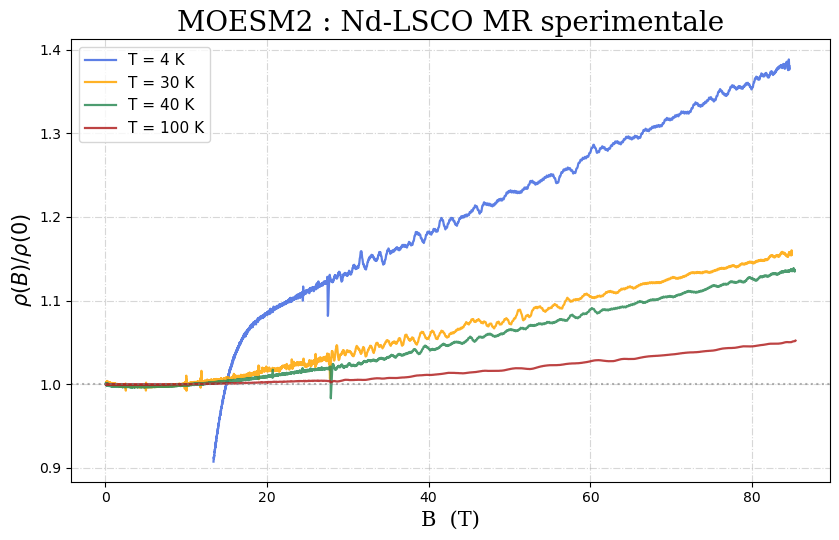

In [21]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for T in T_LIST:
    B, R = DATA[T]
    ax.plot(B, R, color=colors[T], linewidth=1.6, alpha=0.85, label=f'T = {T:.0f} K')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('B  (T)', fontdict=font2)
ax.set_ylabel(r'$\rho(B)/\rho(0)$', fontdict=font2)
ax.set_title('MOESM2 : Nd-LSCO MR sperimentale', fontdict=font1)
ax.legend(fontsize=11)
ax.grid(linestyle='-.', alpha=0.5)
plt.tight_layout()
plt.show()

## Fit Globale

### Fit globale (modello gradino)

In [22]:
MIN_GAMMA_MEV = 1.0
MAX_GAMMA_MEV = 200.0
MIN_PHI   = 0.1
MAX_PHI   = np.pi / 4
beh_phi   = "dec"
MIN_MSTAR = 1.0
MAX_MSTAR = 5.0
MIN_TPHI  = 150.0
MAX_TPHI  = 500.0
T_MAX = max(T_LIST)

lb_step = [
    0.0, MIN_GAMMA_MEV,
    0.0, MIN_GAMMA_MEV,
    MIN_PHI, -(MAX_PHI - MIN_PHI),
    MIN_TPHI, MIN_MSTAR,
]
ub_step = [
    _a_cap(T_DEP['G1'], MAX_GAMMA_MEV, MIN_GAMMA_MEV, T_MAX), MAX_GAMMA_MEV,
    _a_cap(T_DEP['G2'], MAX_GAMMA_MEV, MIN_GAMMA_MEV, T_MAX), MAX_GAMMA_MEV,
    MAX_PHI, (MAX_PHI - MIN_PHI),
    MAX_TPHI, MAX_MSTAR,
]
if beh_phi == "inc":
    ub_step[5] = 0.0
else:
    ub_step[5] = 0.17
    ub_step[4] = 0.61

B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}

loss_step = build_loss_step_batch(DATA, B_MIN, T_LIST, T_DEP, DEVICE)

best_step, all_step = run_multistart_torch(
    loss_step, lb_step, ub_step,
    N_grid=30_000, N_refine=30, device=DEVICE,
)

a1_opt, c1_opt, a2_opt, c2_opt, phi0_opt, dphi_opt, T_phi_opt, m_star_opt = best_step
rms_step = float(np.sqrt(all_step[0][0]))

_t_g1 = {"linear": "T", "quadratic": "T^2"}[T_DEP["G1"]]
_t_g2 = {"linear": "T", "quadratic": "T^2"}[T_DEP["G2"]]

print('\nGamma_i(T) dal fit globale:')
for T in T_LIST:
    g1 = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2 = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    print(f'  T={T:4.0f} K  Gamma_1={g1:7.3f} meV  Gamma_2={g2:7.3f} meV')

display(Markdown(f"""
**Risultati Fit Globale — modello gradino (Nd-LSCO)**

- $m^{{\\ast}}/m_e = \\mathbf{{{m_star_opt:.4f}}}$
- $\\Gamma_1(T) = {a1_opt:.5f}\\,{_t_g1} + {c1_opt:.3f}$ meV
- $\\Gamma_2(T) = {a2_opt:.5f}\\,{_t_g2} + {c2_opt:.3f}$ meV
- $\\varphi^{{\\ast}}(T) = {np.degrees(phi0_opt):.2f}^\\circ {np.degrees(dphi_opt):+.2f}^\\circ \\tanh(T/{T_phi_opt:.1f}$ K$)$
- RMS $= \\mathbf{{{rms_step:.5f}}}$
"""))

Fase 1 — grid sweep: 30,000 starts su cuda...
  Loss top-30: [0.000601, 0.000775]
Fase 2 — raffinamento 30 candidati (L-BFGS-B + autograd)...


Raffinamento L-BFGS-B:   0%|          | 0/30 [00:00<?, ?it/s]

Miglior loss: 0.00015815  (da 30 candidati)

Gamma_i(T) dal fit globale:
  T=   4 K  Gamma_1= 10.390 meV  Gamma_2= 25.008 meV
  T=  30 K  Gamma_1= 17.732 meV  Gamma_2= 26.461 meV
  T=  40 K  Gamma_1= 23.545 meV  Gamma_2= 27.611 meV
  T= 100 K  Gamma_1= 93.307 meV  Gamma_2= 41.415 meV



**Risultati Fit Globale — modello gradino (Nd-LSCO)**

- $m^{\ast}/m_e = \mathbf{1.0026}$
- $\Gamma_1(T) = 0.00831\,T^2 + 10.257$ meV
- $\Gamma_2(T) = 0.00164\,T^2 + 24.982$ meV
- $\varphi^{\ast}(T) = 13.31^\circ -31.64^\circ \tanh(T/223.0$ K$)$
- RMS $= \mathbf{0.01258}$


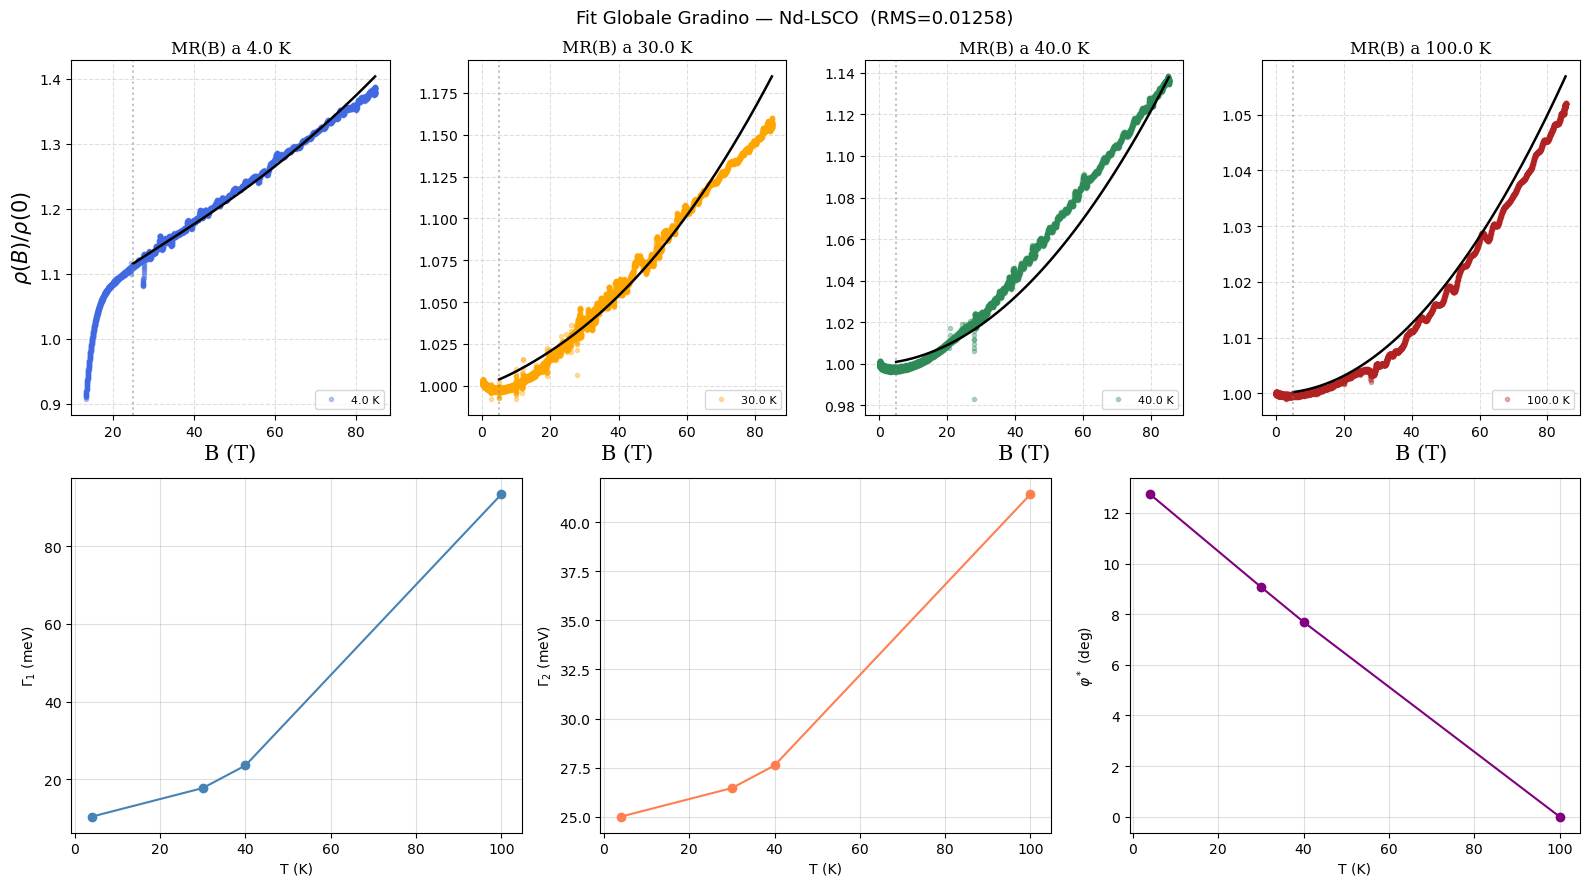

In [23]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 12, figure=fig)
axs_mr = [fig.add_subplot(gs[0, 0:3]), fig.add_subplot(gs[0, 3:6]),
          fig.add_subplot(gs[0, 6:9]), fig.add_subplot(gs[0, 9:12])]
ax_g1 = fig.add_subplot(gs[1, 0:4])
ax_g2 = fig.add_subplot(gs[1, 4:8])
ax_ph = fig.add_subplot(gs[1, 8:12])

for i, T in enumerate(T_LIST):
    ax = axs_mr[i]
    B, R = DATA[T]
    sel  = B > B_MIN[T]
    g1_T = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2_T = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    ph_T = eval_phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt)
    ax.plot(B, R, 'o', color=colors[T], markersize=3, alpha=0.35, label=f'{T} K')
    B_pl = np.linspace(B[sel].min(), B.max(), 200)
    ax.plot(B_pl, 1.0 + cl.mr_step(B_pl, g1_T, g2_T, ph_T, m_star_opt), 'k-', lw=1.8)
    ax.axvline(B_MIN[T], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'MR(B) a {T} K', fontdict=font1, fontsize=12)
    ax.set_xlabel('B (T)', fontdict=font2)
    if i == 0:
        ax.set_ylabel(r'$\rho(B)/\rho(0)$', fontdict=font2)
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

T_pl = np.array(T_LIST)
g1_pl = [eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1']) for T in T_pl]
g2_pl = [eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2']) for T in T_pl]
ph_pl = [np.degrees(eval_phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt)) for T in T_pl]

ax_g1.plot(T_pl, g1_pl, 'o-', color='steelblue'); ax_g1.set_ylabel(r'$\Gamma_1$ (meV)'); ax_g1.grid(alpha=0.4)
ax_g2.plot(T_pl, g2_pl, 'o-', color='coral');     ax_g2.set_ylabel(r'$\Gamma_2$ (meV)'); ax_g2.grid(alpha=0.4)
ax_ph.plot(T_pl, ph_pl, 'o-', color='purple');    ax_ph.set_ylabel(r'$\varphi^*$ (deg)'); ax_ph.grid(alpha=0.4)
for ax in [ax_g1, ax_g2, ax_ph]: ax.set_xlabel('T (K)')

fig.suptitle(f'Fit Globale Gradino — Nd-LSCO  (RMS={rms_step:.5f})', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
rows = []
for T in T_LIST:
    g1 = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2 = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    ph = np.degrees(eval_phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt))
    rows.append(f'| {T:g} | {g1:.3f} | {g2:.3f} | {ph:.2f} | {m_star_opt:.3f} |')

display(Markdown(
    '**Tabella — fit globale gradino (Nd-LSCO)**\n\n'
    '| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\\varphi^*$ (deg) | $m^*/m_e$ |\n'
    '|---:|---:|---:|---:|---:|\n' + '\n'.join(rows)
))

**Tabella — fit globale gradino (Nd-LSCO)**

| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\varphi^*$ (deg) | $m^*/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 10.390 | 25.008 | 12.74 | 1.003 |
| 30 | 17.732 | 26.461 | 9.08 | 1.003 |
| 40 | 23.545 | 27.611 | 7.69 | 1.003 |
| 100 | 93.307 | 41.415 | 0.00 | 1.003 |

### Fit globale (modello Bessel)

In [15]:
MAX_GAMMA_MEV_B = 100.0
C_MAX_B         = 30.0
T_MAX_B         = max(T_LIST)

def _unpack_bessel_nd(p, T):
    a_is, c_is, a_an, c_an, m_star = p
    Gi = eval_T_dep(T, a_is, c_is, T_DEP['G_is'])
    Ga = eval_T_dep(T, a_an, c_an, T_DEP['G_an'])
    return Gi, Ga, m_star

loss_bess_nd = build_loss_bessel_np(DATA, B_MIN, T_LIST, _unpack_bessel_nd)

lb_b = [0.0, 0.0, 0.0, 0.0, 1.0]
ub_b = [
    _a_cap(T_DEP['G_is'], MAX_GAMMA_MEV_B, C_MAX_B, T_MAX_B), C_MAX_B,
    _a_cap(T_DEP['G_an'], MAX_GAMMA_MEV_B, C_MAX_B, T_MAX_B), C_MAX_B,
    5.0,
]

best_b_nd, all_b_nd = run_multistart_joblib(
    loss_bess_nd, lb_b, ub_b,
    N_grid=3_000, N_refine=30,
)

a_is_opt, c_is_opt, a_an_opt, c_an_opt, m_star_b_opt = best_b_nd
rms_bessel = float(np.sqrt(all_b_nd[0][0]))

_t_gi = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_is"]]
_t_ga = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_an"]]

print('\nGamma_i(T) dal fit globale Bessel:')
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    print(f'  T={T:4.0f} K  Gamma_is={gi:7.3f} meV  Gamma_an={ga:7.3f} meV')

display(Markdown(f"""
**Risultati Fit Globale — modello Bessel (Nd-LSCO)**

- $m^{{\\ast}}/m_e = \\mathbf{{{m_star_b_opt:.4f}}}$
- $\\Gamma_{{\\rm is}}(T) = {a_is_opt:.5f}\\,{_t_gi} + {c_is_opt:.3f}$ meV
- $\\Gamma_{{\\rm an}}(T) = {a_an_opt:.5f}\\,{_t_ga} + {c_an_opt:.3f}$ meV
- RMS $= \\mathbf{{{rms_bessel:.5f}}}$
"""))

Fase 1 — grid sweep: 3,000 starts (joblib n_jobs=-1)...
  Loss top-30: [0.000488, 0.002003]
Fase 2 — raffinamento 30 candidati (joblib n_jobs=-1)...
Miglior loss: 0.00025286  (da 30 candidati paralleli)

Gamma_i(T) dal fit globale Bessel:
  T=   4 K  Gamma_is=  6.686 meV  Gamma_an= 28.046 meV
  T=  30 K  Gamma_is= 13.095 meV  Gamma_an= 41.368 meV
  T=  40 K  Gamma_is= 15.561 meV  Gamma_an= 46.492 meV
  T= 100 K  Gamma_is= 30.352 meV  Gamma_an= 77.236 meV



**Risultati Fit Globale — modello Bessel (Nd-LSCO)**

- $m^{\ast}/m_e = \mathbf{1.8214}$
- $\Gamma_{\rm is}(T) = 0.24652\,T + 5.700$ meV
- $\Gamma_{\rm an}(T) = 0.51239\,T + 25.996$ meV
- RMS $= \mathbf{0.01590}$


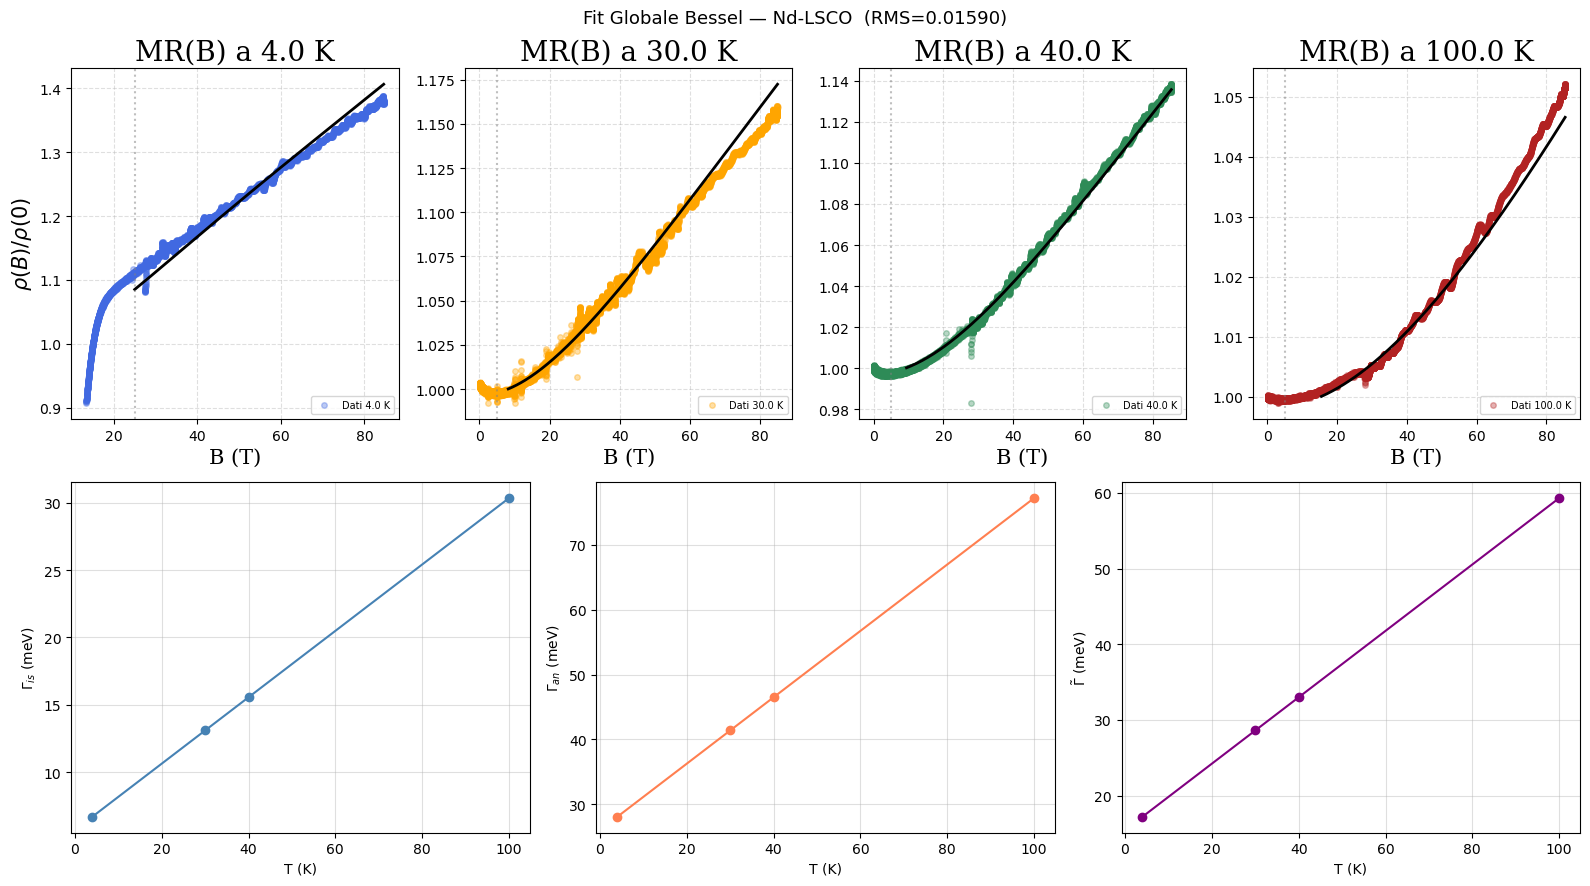

In [16]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 12, figure=fig)
axs_mr = [fig.add_subplot(gs[0, 0:3]), fig.add_subplot(gs[0, 3:6]),
          fig.add_subplot(gs[0, 6:9]), fig.add_subplot(gs[0, 9:12])]
ax_gi = fig.add_subplot(gs[1, 0:4])
ax_ga = fig.add_subplot(gs[1, 4:8])
ax_gt = fig.add_subplot(gs[1, 8:12])

for i, T in enumerate(T_LIST):
    ax   = axs_mr[i]
    B, R = DATA[T]
    sel  = B > B_MIN[T]
    gi_T = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga_T = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    ax.plot(B, R, 'o', color=colors[T], markersize=4, alpha=0.35, label=f'Dati {T} K')
    B_pl = np.linspace(B[sel].min(), B.max(), 200)
    R_pl = 1.0 + cl.MR_Bessel(B_pl, gi_T, ga_T, m_star_b_opt)
    ax.plot(B_pl, np.where(np.isfinite(R_pl), R_pl, np.nan), '-', color='black', lw=2)
    ax.axvline(B_MIN[T], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'MR(B) a {T} K', fontdict=font1)
    ax.set_xlabel('B (T)', fontdict=font2)
    if i == 0:
        ax.set_ylabel(r'$\rho(B)/\rho(0)$', fontdict=font2)
    ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.4)

T_pl  = np.array(T_LIST)
gi_pl = [eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is']) for T in T_pl]
ga_pl = [eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an']) for T in T_pl]
gt_pl = [gi + 3/8*ga for gi, ga in zip(gi_pl, ga_pl)]

ax_gi.plot(T_pl, gi_pl, 'o-', color='steelblue'); ax_gi.set_ylabel(r'$\Gamma_{is}$ (meV)'); ax_gi.grid(alpha=0.4)
ax_ga.plot(T_pl, ga_pl, 'o-', color='coral');     ax_ga.set_ylabel(r'$\Gamma_{an}$ (meV)'); ax_ga.grid(alpha=0.4)
ax_gt.plot(T_pl, gt_pl, 'o-', color='purple');    ax_gt.set_ylabel(r'$\tilde\Gamma$ (meV)'); ax_gt.grid(alpha=0.4)
for ax in [ax_gi, ax_ga, ax_gt]: ax.set_xlabel('T (K)')
fig.suptitle(f'Fit Globale Bessel — Nd-LSCO  (RMS={rms_bessel:.5f})', fontsize=13)
plt.tight_layout(); plt.show()

In [17]:
rows_b = []
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    rows_b.append(f'| {T:g} | {gi:.3f} | {ga:.3f} | {gi+3/8*ga:.3f} | {m_star_b_opt:.3f} |')

display(Markdown(
    '**Tabella — fit globale Bessel (Nd-LSCO)**\n\n'
    '| T (K) | $\Gamma_{is}$ (meV) | $\Gamma_{an}$ (meV) | $\tilde\Gamma$ (meV) | $m^*/m_e$ |\n'
    '|---:|---:|---:|---:|---:|\n' + '\n'.join(rows_b)
))

**Tabella — fit globale Bessel (Nd-LSCO)**

| T (K) | $\Gamma_{is}$ (meV) | $\Gamma_{an}$ (meV) | $	ilde\Gamma$ (meV) | $m^*/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 6.686 | 28.046 | 17.203 | 1.821 |
| 30 | 13.095 | 41.368 | 28.608 | 1.821 |
| 40 | 15.561 | 46.492 | 32.995 | 1.821 |
| 100 | 30.352 | 77.236 | 59.315 | 1.821 |

# MOESM4: MR sperimentale LSCO S1

Stessa struttura della Sezione 2, campione **LSCO S1**.

## Dati

In [18]:
arr_s1 = cl.load_ataei_extended([4, 6])

T_MAPPING_S1 = {4.0: (0, 1), 30.0: (6, 7), 40.0: (2, 3), 100.0: (4, 5)}
T_LIST  = [4.0, 30.0, 40.0, 100.0]
colors  = {4.0: "royalblue", 30.0: "orange", 40.0: "seagreen", 100.0: "firebrick"}

DATA = {}
for T in T_LIST:
    iB, iR = T_MAPPING_S1[T]
    B, R   = arr_s1[:, iB], arr_s1[:, iR]
    m      = np.isfinite(B) & np.isfinite(R) & (B > 0)
    DATA[T] = (B[m], R[m])
    print(f"T = {T:4.0f} K : N = {m.sum():5d}  B in [{B[m].min():.2f}, {B[m].max():.2f}] T")

T =    4 K : N =  1851  B in [23.05, 64.47] T
T =   30 K : N =  6749  B in [0.20, 64.49] T
T =   40 K : N =  8069  B in [0.02, 64.64] T
T =  100 K : N =  8051  B in [0.02, 64.76] T


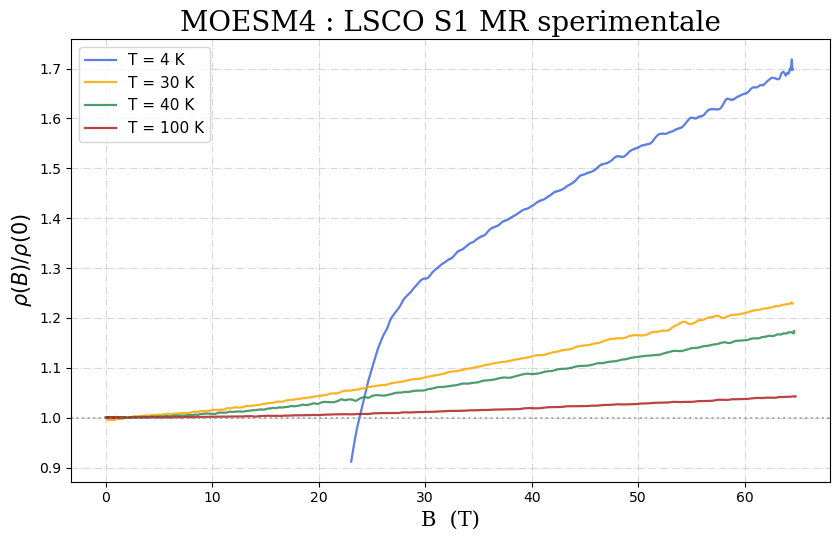

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for T in T_LIST:
    B, R = DATA[T]
    ax.plot(B, R, color=colors[T], linewidth=1.6, alpha=0.85, label=f'T = {T:.0f} K')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('B  (T)', fontdict=font2)
ax.set_ylabel(r'$\rho(B)/\rho(0)$', fontdict=font2)
ax.set_title('MOESM4 : LSCO S1 MR sperimentale', fontdict=font1)
ax.legend(fontsize=11)
ax.grid(linestyle='-.', alpha=0.5)
plt.tight_layout(); plt.show()

## Fit Globale

### Fit globale (modello gradino)

In [22]:
MAX_GAMMA_MEV = 100.0
C_MAX         = 30.0
T_MAX         = max(T_LIST)
beh_phi = "dec"

lb_step_s1 = [0.0, 0.0, 0.0, 0.0, 0.0, -cl.PHI_MAX, 1.0, 0.5]
ub_step_s1 = [
    _a_cap(T_DEP['G1'], MAX_GAMMA_MEV, C_MAX, T_MAX), C_MAX,
    _a_cap(T_DEP['G2'], MAX_GAMMA_MEV, C_MAX, T_MAX), C_MAX,
    cl.PHI_MAX, 0.0, 500.0, 15.0,
]

B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
loss_step_s1 = build_loss_step_batch(DATA, B_MIN, T_LIST, T_DEP, DEVICE)

best_step_s1, all_step_s1 = run_multistart_torch(
    loss_step_s1, lb_step_s1, ub_step_s1,
    N_grid=30_000, N_refine=30, device=DEVICE,
)

a1_opt, c1_opt, a2_opt, c2_opt, phi0_opt, dphi_opt, T_phi_opt, m_star_opt = best_step_s1
rms_step = float(np.sqrt(all_step_s1[0][0]))

_t_g1 = {"linear": "T", "quadratic": "T^2"}[T_DEP["G1"]]
_t_g2 = {"linear": "T", "quadratic": "T^2"}[T_DEP["G2"]]

print('\nGamma_i(T) dal fit globale:')
for T in T_LIST:
    g1 = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2 = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    print(f'  T={T:4.0f} K  Gamma_1={g1:7.3f} meV  Gamma_2={g2:7.3f} meV')

display(Markdown(f"""
**Risultati Fit Globale — modello gradino (LSCO S1)**

- $m^{{\\ast}}/m_e = \\mathbf{{{m_star_opt:.4f}}}$
- $\\Gamma_1(T) = {a1_opt:.5f}\\,{_t_g1} + {c1_opt:.3f}$ meV
- $\\Gamma_2(T) = {a2_opt:.5f}\\,{_t_g2} + {c2_opt:.3f}$ meV
- $\\varphi^{{\\ast}}(T) = {np.degrees(phi0_opt):.2f}^\\circ {np.degrees(dphi_opt):+.2f}^\\circ \\tanh(T/{T_phi_opt:.1f}$ K$)$
- RMS $= \\mathbf{{{rms_step:.5f}}}$
"""))

Fase 1 — grid sweep: 30,000 starts su cuda...
  Loss top-30: [0.014528, 0.136528]
Fase 2 — raffinamento 30 candidati (L-BFGS-B + autograd)...


Raffinamento L-BFGS-B:   0%|          | 0/30 [00:00<?, ?it/s]

Miglior loss: 0.00099091  (da 30 candidati)

Gamma_i(T) dal fit globale:
  T=   4 K  Gamma_1=  9.594 meV  Gamma_2=  0.003 meV
  T=  30 K  Gamma_1= 22.534 meV  Gamma_2=  0.006 meV
  T=  40 K  Gamma_1= 27.510 meV  Gamma_2=  0.010 meV
  T= 100 K  Gamma_1= 57.370 meV  Gamma_2=  0.046 meV



**Risultati Fit Globale — modello gradino (LSCO S1)**

- $m^{\ast}/m_e = \mathbf{8.8371}$
- $\Gamma_1(T) = 0.49766\,T + 7.604$ meV
- $\Gamma_2(T) = 0.00000\,T^2 + 0.002$ meV
- $\varphi^{\ast}(T) = 0.01^\circ -0.00^\circ \tanh(T/401.6$ K$)$
- RMS $= \mathbf{0.03148}$


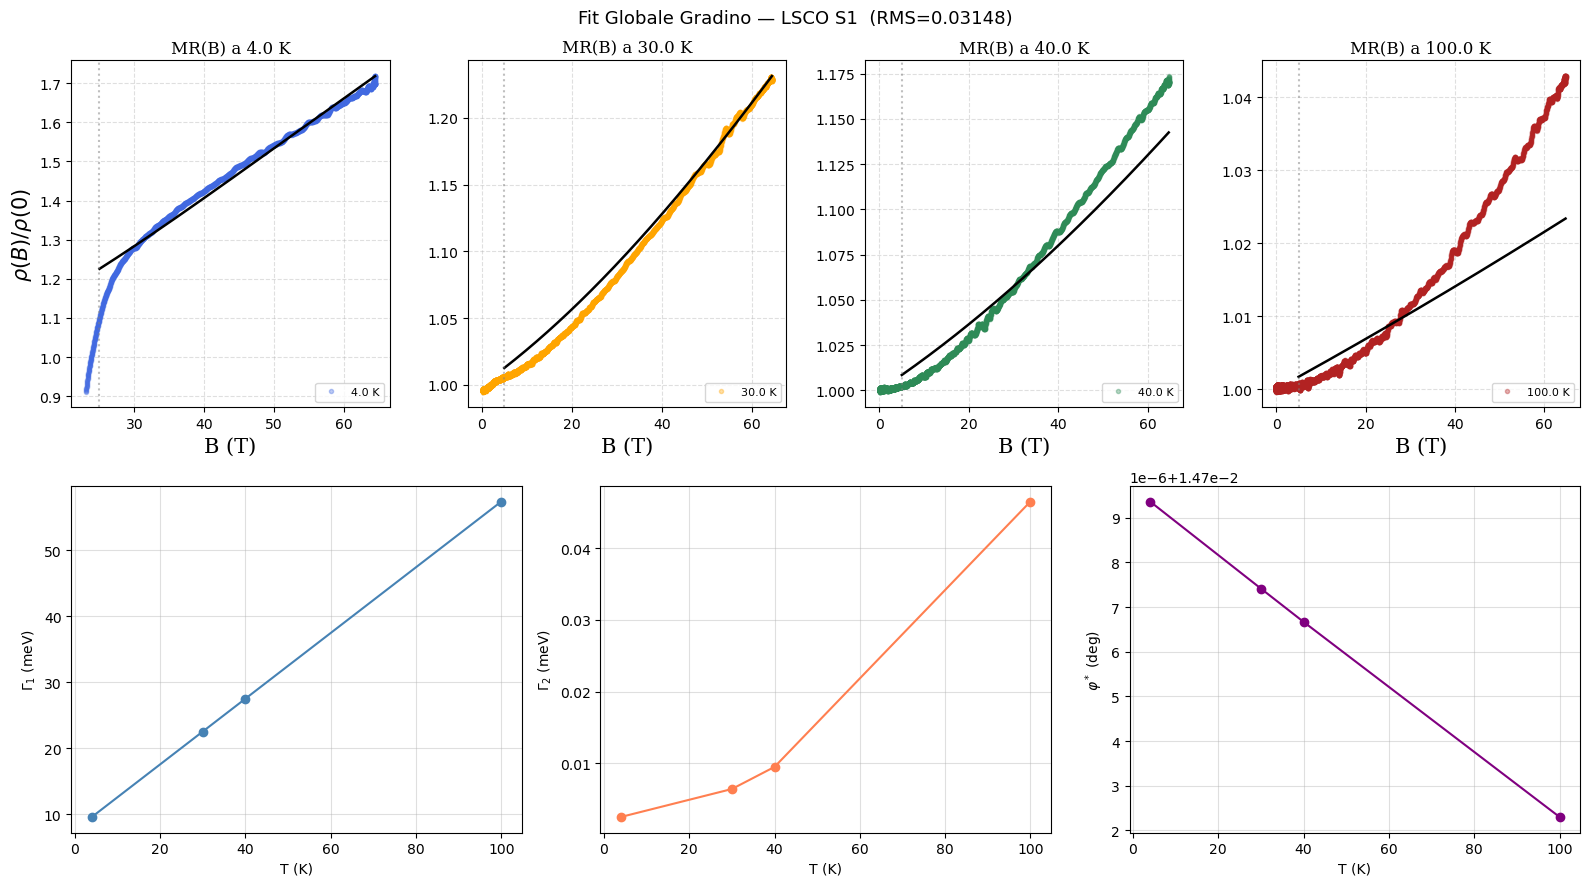

In [23]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 12, figure=fig)
axs_mr = [fig.add_subplot(gs[0, 0:3]), fig.add_subplot(gs[0, 3:6]),
          fig.add_subplot(gs[0, 6:9]), fig.add_subplot(gs[0, 9:12])]
ax_g1 = fig.add_subplot(gs[1, 0:4])
ax_g2 = fig.add_subplot(gs[1, 4:8])
ax_ph = fig.add_subplot(gs[1, 8:12])
for i, T in enumerate(T_LIST):
    ax = axs_mr[i]
    B, R = DATA[T]; sel = B > B_MIN[T]
    g1_T = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2_T = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    ph_T = eval_phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt)
    ax.plot(B, R, 'o', color=colors[T], markersize=3, alpha=0.35, label=f'{T} K')
    B_pl = np.linspace(B[sel].min(), B.max(), 200)
    ax.plot(B_pl, 1.0 + cl.mr_step(B_pl, g1_T, g2_T, ph_T, m_star_opt), 'k-', lw=1.8)
    ax.axvline(B_MIN[T], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'MR(B) a {T} K', fontdict=font1, fontsize=12)
    ax.set_xlabel('B (T)', fontdict=font2)
    if i == 0:
        ax.set_ylabel(r'$\rho(B)/\rho(0)$', fontdict=font2)
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)
T_pl = np.array(T_LIST)
g1_pl = [eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1']) for T in T_pl]
g2_pl = [eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2']) for T in T_pl]
ph_pl = [np.degrees(eval_phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt)) for T in T_pl]
ax_g1.plot(T_pl, g1_pl, 'o-', color='steelblue'); ax_g1.set_ylabel(r'$\Gamma_1$ (meV)'); ax_g1.grid(alpha=0.4)
ax_g2.plot(T_pl, g2_pl, 'o-', color='coral');     ax_g2.set_ylabel(r'$\Gamma_2$ (meV)'); ax_g2.grid(alpha=0.4)
ax_ph.plot(T_pl, ph_pl, 'o-', color='purple');    ax_ph.set_ylabel(r'$\varphi^*$ (deg)'); ax_ph.grid(alpha=0.4)
for ax in [ax_g1, ax_g2, ax_ph]: ax.set_xlabel('T (K)')
fig.suptitle(f'Fit Globale Gradino — LSCO S1  (RMS={rms_step:.5f})', fontsize=13)
plt.tight_layout(); plt.show()

In [25]:
rows = []
for T in T_LIST:
    g1 = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2 = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    ph = np.degrees(eval_phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt))
    rows.append(f'| {T:g} | {g1:.3f} | {g2:.3f} | {ph:.2f} | {m_star_opt:.3f} |')
display(Markdown(
    '**Tabella — fit globale gradino (LSCO S1)**\n\n'
    '| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\\varphi^*$ (deg) | $m^*/m_e$ |\n'
    '|---:|---:|---:|---:|---:|\n' + '\n'.join(rows)
))

**Tabella — fit globale gradino (LSCO S1)**

| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\varphi^*$ (deg) | $m^*/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 9.594 | 0.003 | 0.01 | 8.837 |
| 30 | 22.534 | 0.006 | 0.01 | 8.837 |
| 40 | 27.510 | 0.010 | 0.01 | 8.837 |
| 100 | 57.370 | 0.046 | 0.01 | 8.837 |

### Fit globale (modello Bessel)

In [26]:
def _unpack_bessel_s1(p, T):
    a_is, c_is, a_an, c_an, m_star = p
    return eval_T_dep(T, a_is, c_is, T_DEP['G_is']), \
           eval_T_dep(T, a_an, c_an, T_DEP['G_an']), m_star

loss_bess_s1 = build_loss_bessel_np(DATA, B_MIN, T_LIST, _unpack_bessel_s1)

lb_b_s1 = [0.0, 0.0, 0.0, 0.0, 4.0]
ub_b_s1 = [
    _a_cap(T_DEP['G_is'], 100.0, 30.0, max(T_LIST)), 30.0,
    _a_cap(T_DEP['G_an'], 100.0, 30.0, max(T_LIST)), 30.0,
    10.0,
]

best_b_s1, all_b_s1 = run_multistart_joblib(
    loss_bess_s1, lb_b_s1, ub_b_s1, N_grid=3_000, N_refine=30,
)

a_is_opt, c_is_opt, a_an_opt, c_an_opt, m_star_b_opt = best_b_s1
rms_bessel = float(np.sqrt(all_b_s1[0][0]))
_t_gi = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_is"]]
_t_ga = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_an"]]
print('\nGamma_i(T) dal fit globale Bessel:')
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    print(f'  T={T:4.0f} K  Gamma_is={gi:7.3f} meV  Gamma_an={ga:7.3f} meV')
display(Markdown(f"""
**Risultati Fit Globale — modello Bessel (LSCO S1)**
- $m^{{\\ast}}/m_e = \\mathbf{{{m_star_b_opt:.4f}}}$
- $\\Gamma_{{\\rm is}}(T) = {a_is_opt:.5f}\\,{_t_gi} + {c_is_opt:.3f}$ meV
- $\\Gamma_{{\\rm an}}(T) = {a_an_opt:.5f}\\,{_t_ga} + {c_an_opt:.3f}$ meV
- RMS $= \\mathbf{{{rms_bessel:.5f}}}$
"""))

Fase 1 — grid sweep: 3,000 starts (joblib n_jobs=-1)...
  Loss top-30: [0.000000, 0.000000]
Fase 2 — raffinamento 30 candidati (joblib n_jobs=-1)...
Miglior loss: 0.00000000  (da 30 candidati paralleli)

Gamma_i(T) dal fit globale Bessel:
  T=   4 K  Gamma_is=  9.018 meV  Gamma_an= 30.766 meV
  T=  30 K  Gamma_is= 12.110 meV  Gamma_an= 36.441 meV
  T=  40 K  Gamma_is= 13.300 meV  Gamma_an= 38.624 meV
  T= 100 K  Gamma_is= 20.435 meV  Gamma_an= 51.721 meV



**Risultati Fit Globale — modello Bessel (LSCO S1)**
- $m^{\ast}/m_e = \mathbf{5.2874}$
- $\Gamma_{\rm is}(T) = 0.11893\,T + 8.543$ meV
- $\Gamma_{\rm an}(T) = 0.21828\,T + 29.893$ meV
- RMS $= \mathbf{0.00000}$


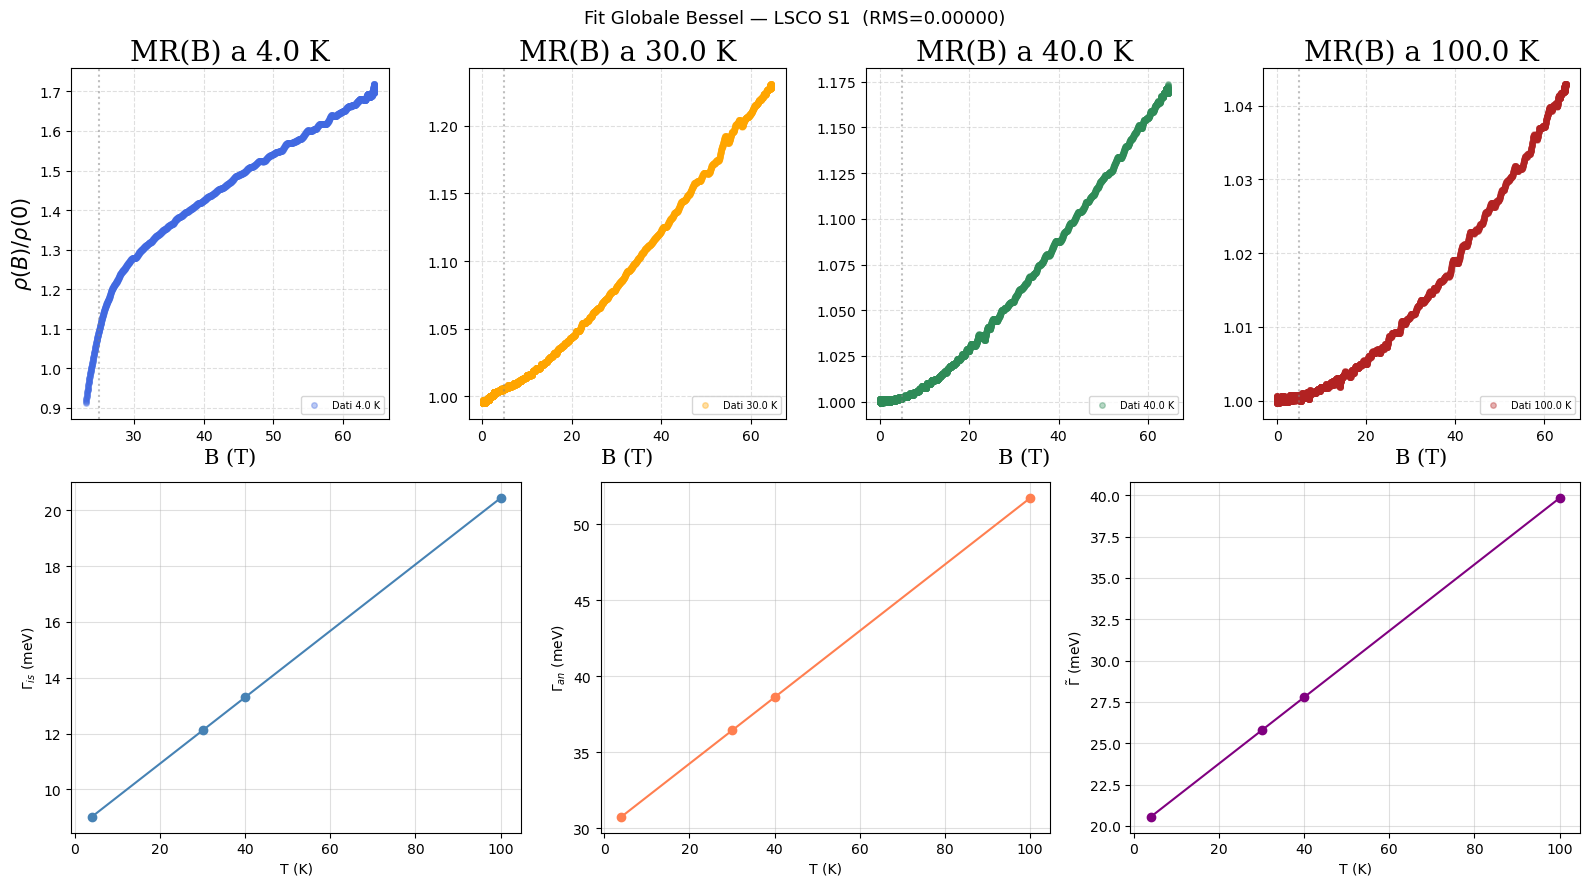

In [27]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 12, figure=fig)
axs_mr = [fig.add_subplot(gs[0, 0:3]), fig.add_subplot(gs[0, 3:6]),
          fig.add_subplot(gs[0, 6:9]), fig.add_subplot(gs[0, 9:12])]
ax_gi = fig.add_subplot(gs[1, 0:4]); ax_ga = fig.add_subplot(gs[1, 4:8]); ax_gt = fig.add_subplot(gs[1, 8:12])
for i, T in enumerate(T_LIST):
    ax = axs_mr[i]; B, R = DATA[T]; sel = B > B_MIN[T]
    gi_T = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga_T = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    ax.plot(B, R, 'o', color=colors[T], markersize=4, alpha=0.35, label=f'Dati {T} K')
    B_pl = np.linspace(B[sel].min(), B.max(), 200)
    R_pl = 1.0 + cl.MR_Bessel(B_pl, gi_T, ga_T, m_star_b_opt)
    ax.plot(B_pl, np.where(np.isfinite(R_pl), R_pl, np.nan), '-k', lw=2)
    ax.axvline(B_MIN[T], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'MR(B) a {T} K', fontdict=font1); ax.set_xlabel('B (T)', fontdict=font2)
    if i == 0:
        ax.set_ylabel(r'$\rho(B)/\rho(0)$', fontdict=font2)
    ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.4)
T_pl  = np.array(T_LIST)
gi_pl = [eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is']) for T in T_pl]
ga_pl = [eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an']) for T in T_pl]
ax_gi.plot(T_pl, gi_pl, 'o-', color='steelblue'); ax_gi.set_ylabel(r'$\Gamma_{is}$ (meV)'); ax_gi.grid(alpha=0.4)
ax_ga.plot(T_pl, ga_pl, 'o-', color='coral');     ax_ga.set_ylabel(r'$\Gamma_{an}$ (meV)'); ax_ga.grid(alpha=0.4)
ax_gt.plot(T_pl, [g+3/8*a for g,a in zip(gi_pl,ga_pl)], 'o-', color='purple'); ax_gt.set_ylabel(r'$\tilde\Gamma$ (meV)'); ax_gt.grid(alpha=0.4)
for ax in [ax_gi, ax_ga, ax_gt]: ax.set_xlabel('T (K)')
fig.suptitle(f'Fit Globale Bessel — LSCO S1  (RMS={rms_bessel:.5f})', fontsize=13)
plt.tight_layout(); plt.show()

In [29]:
rows_b = []
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    rows_b.append(f'| {T:g} | {gi:.3f} | {ga:.3f} | {gi+3/8*ga:.3f} | {m_star_b_opt:.3f} |')
display(Markdown(
    '**Tabella — fit globale Bessel (LSCO S1)**\n\n'
    '| T (K) | $\Gamma_{is}$ (meV) | $\Gamma_{an}$ (meV) | $\\tilde\Gamma$ (meV) | $m^*/m_e$ |\n'
    '|---:|---:|---:|---:|---:|\n' + '\n'.join(rows_b)
))

**Tabella — fit globale Bessel (LSCO S1)**

| T (K) | $\Gamma_{is}$ (meV) | $\Gamma_{an}$ (meV) | $\tilde\Gamma$ (meV) | $m^*/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 9.018 | 30.766 | 20.556 | 5.287 |
| 30 | 12.110 | 36.441 | 25.776 | 5.287 |
| 40 | 13.300 | 38.624 | 27.784 | 5.287 |
| 100 | 20.435 | 51.721 | 39.830 | 5.287 |

# Fit Globale Nd-LSCO con calibrazione da A153 (Modello Bessel)
Da **Magnetoresistence.ipynb**: $\Gamma_{is}=17.7\ \text{meV}$, $\Gamma_{an}=39\ \text{meV}$ a $T=30\ \text{K}$, $m^*=1.48784\,m_e$.

$$\Gamma_i(T) = a_i(T^p - 30^p) + \Gamma_i(30\,\text{K})$$

**4 parametri liberi**: $a_{is},\,a_{an},\,\Gamma_{is}(30),\,\Gamma_{an}(30)$.

## Dati

In [22]:
arr = cl.load_ataei_extended([2, 6])
T_MAPPING = {4.0: (0, 1), 30.0: (10, 11), 40.0: (2, 3), 100.0: (4, 5)}
T_LIST  = [4.0, 30.0, 40.0, 100.0]
colors  = {4.0: "royalblue", 30.0: "orange", 40.0: "seagreen", 100.0: "firebrick"}
DATA = {}
for T in T_LIST:
    iB, iR = T_MAPPING[T]
    B, R   = arr[:, iB], arr[:, iR]
    m      = np.isfinite(B) & np.isfinite(R) & (B > 0)
    DATA[T] = (B[m], R[m])
    print(f"T = {T:4.0f} K : N = {m.sum():5d}")

T =    4 K : N =  3872
T =   30 K : N =  9427
T =   40 K : N = 10272
T =  100 K : N =  9895


## Fit (Bessel, $\Gamma_{is/an}(30\,\text{K})$ vincolati attorno ai valori A153)

In [29]:
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}

def _unpack_bessel_cal(p, T):
    a_is, a_an, G_is_30, G_an_30 = p
    p_is = 2 if T_DEP['G_is'] == 'quadratic' else 1
    p_an = 2 if T_DEP['G_an'] == 'quadratic' else 1
    
    c_is = G_is_30 - a_is * (30.0**p_is)
    c_an = G_an_30 - a_an * (30.0**p_an)
    
    gi = eval_T_dep(T, a_is, c_is, T_DEP['G_is'])
    ga = eval_T_dep(T, a_an, c_an, T_DEP['G_an'])
    
    # FIX OVERFLOW: Salvavita fisico. 
    # Impedisce a Gamma di diventare negativo e far esplodere l'esponenziale di Chambers!
    gi = max(gi, 0.1)
    ga = max(ga, 0.1)
    
    return gi, ga, 1.48784

loss_bess_cal = build_loss_bessel_np(DATA, B_MIN, T_LIST, _unpack_bessel_cal)

# 1. Limiti corretti (Bounds)
# Abbassiamo drasticamente il massimo per 'a' (adatto per modelli quadratici)
lb_cal = [0.0, 0.0, 1.0, 1.0]
ub_cal = [0.3, 0.3, 40.0, 80.0]

# 2. Esecuzione Fit
best_cal, all_cal = run_multistart_joblib(
    loss_bess_cal, lb_cal, ub_cal, N_grid=15_000, N_refine=50,
)

a_is_opt, a_an_opt, G_is_30_opt, G_an_30_opt = best_cal
rms_cal = float(np.sqrt(all_cal[0][0]))
p_is = 2 if T_DEP['G_is'] == 'quadratic' else 1
p_an = 2 if T_DEP['G_an'] == 'quadratic' else 1
c_is_opt = G_is_30_opt - a_is_opt * (30.0**p_is)
c_an_opt = G_an_30_opt - a_an_opt * (30.0**p_an)

_t_gi = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_is"]]
_t_ga = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_an"]]

print('\nGamma_i(T) dal fit calibrato:')
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    print(f'  T={T:4.0f} K  Gamma_is={gi:7.3f} meV  Gamma_an={ga:7.3f} meV')

display(Markdown(f"""
**Risultati Fit Globale Bessel calibrato (Nd-LSCO)**
- $m^{{\\ast}}/m_e = \\mathbf{{1.48784}}$ *(fissato)*
- Valori 30 K: $\\Gamma_{{\\rm is}} = {G_is_30_opt:.2f}$ meV, $\\Gamma_{{\\rm an}} = {G_an_30_opt:.2f}$ meV
- $\\Gamma_{{\\rm is}}(T) = {a_is_opt:.6f}\\,{_t_gi} {c_is_opt:+.3f}$ meV
- $\\Gamma_{{\\rm an}}(T) = {a_an_opt:.6f}\\,{_t_ga} {c_an_opt:+.3f}$ meV
- RMS $= \\mathbf{{{rms_cal:.5f}}}$
"""))

Fase 1 — grid sweep: 15,000 starts (joblib n_jobs=-1)...
  Loss top-50: [0.000270, 0.000707]
Fase 2 — raffinamento 50 candidati (joblib n_jobs=-1)...
Miglior loss: 0.00026625  (da 50 candidati paralleli)

Gamma_i(T) dal fit calibrato:
  T=   4 K  Gamma_is=  8.224 meV  Gamma_an= 35.664 meV
  T=  30 K  Gamma_is= 15.376 meV  Gamma_an= 37.022 meV
  T=  40 K  Gamma_is= 18.127 meV  Gamma_an= 37.545 meV
  T= 100 K  Gamma_is= 34.632 meV  Gamma_an= 40.680 meV



**Risultati Fit Globale Bessel calibrato (Nd-LSCO)**
- $m^{\ast}/m_e = \mathbf{1.48784}$ *(fissato)*
- Valori 30 K: $\Gamma_{\rm is} = 15.38$ meV, $\Gamma_{\rm an} = 37.02$ meV
- $\Gamma_{\rm is}(T) = 0.275082\,T +7.124$ meV
- $\Gamma_{\rm an}(T) = 0.052256\,T +35.455$ meV
- RMS $= \mathbf{0.01632}$


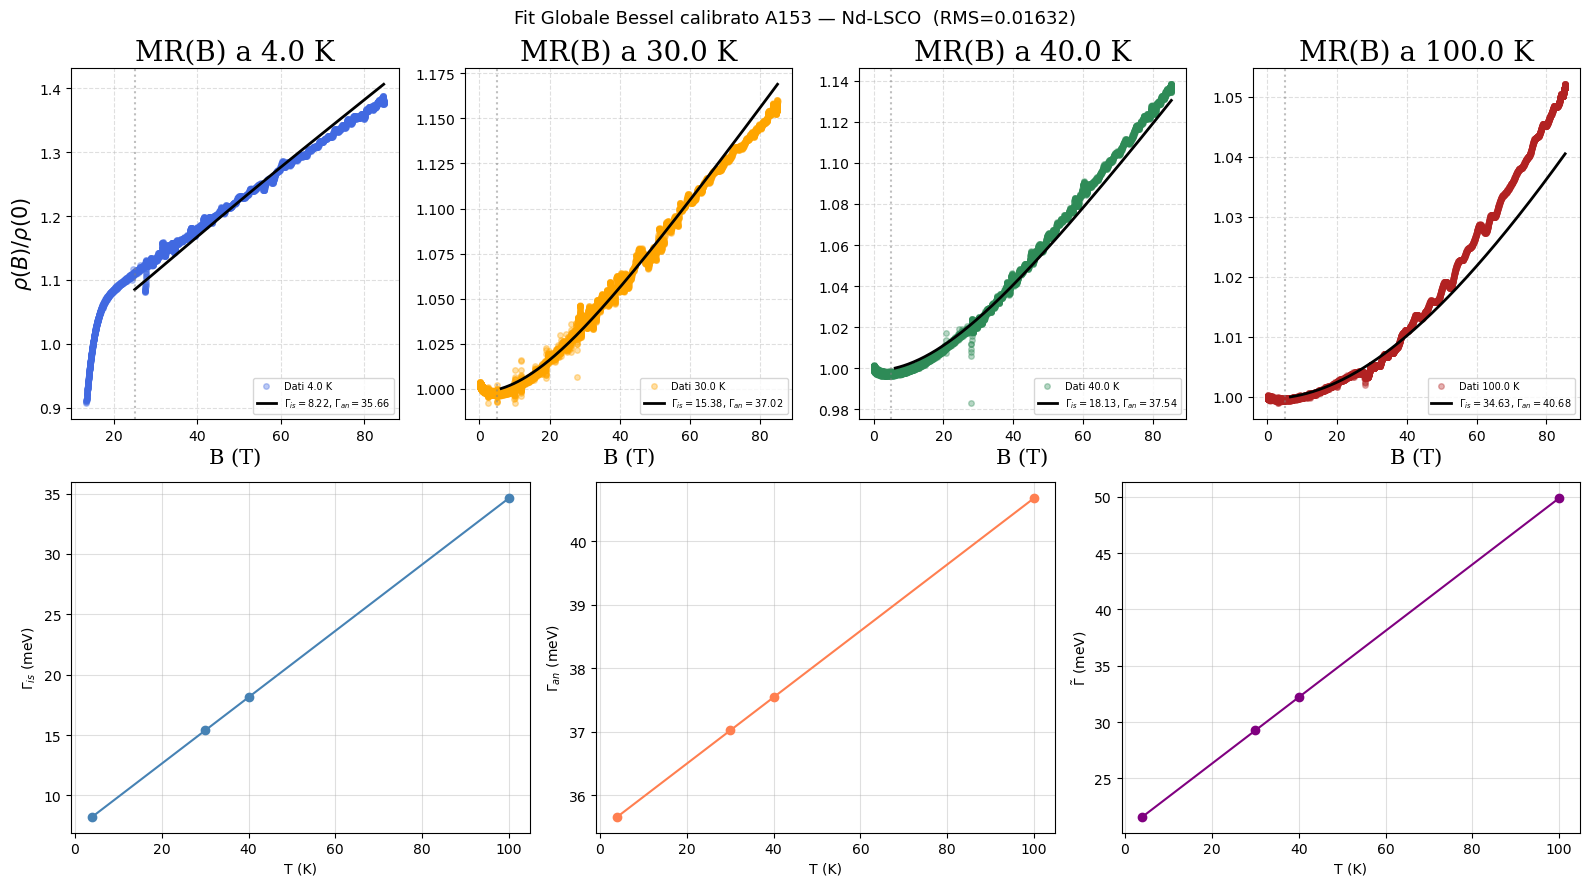

In [31]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 12, figure=fig)
axs_mr = [fig.add_subplot(gs[0, 0:3]), fig.add_subplot(gs[0, 3:6]),
          fig.add_subplot(gs[0, 6:9]), fig.add_subplot(gs[0, 9:12])]
ax_gi = fig.add_subplot(gs[1, 0:4]); ax_ga = fig.add_subplot(gs[1, 4:8]); ax_gt = fig.add_subplot(gs[1, 8:12])
for i, T in enumerate(T_LIST):
    ax = axs_mr[i]; B, R = DATA[T]; sel = B > B_MIN[T]
    gi_T = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga_T = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    ax.plot(B, R, 'o', color=colors[T], markersize=4, alpha=0.35, label=f'Dati {T} K')
    B_pl = np.linspace(B[sel].min(), B.max(), 200)
    R_pl = 1.0 + cl.MR_Bessel(B_pl, gi_T, ga_T, m_star_b_opt)
    ax.plot(B_pl, np.where(np.isfinite(R_pl), R_pl, np.nan), '-k', lw=2,
            label=f'$\\Gamma_{{is}}={gi_T:.2f}$, $\\Gamma_{{an}}={ga_T:.2f}$')
    ax.axvline(B_MIN[T], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'MR(B) a {T} K', fontdict=font1); ax.set_xlabel('B (T)', fontdict=font2)
    if i == 0:
        ax.set_ylabel(r'$\rho(B)/\rho(0)$', fontdict=font2)
    ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.4)
T_pl  = np.array(T_LIST)
gi_pl = [eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is']) for T in T_pl]
ga_pl = [eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an']) for T in T_pl]
ax_gi.plot(T_pl, gi_pl, 'o-', color='steelblue'); ax_gi.set_ylabel(r'$\Gamma_{is}$ (meV)'); ax_gi.grid(alpha=0.4)
ax_ga.plot(T_pl, ga_pl, 'o-', color='coral');     ax_ga.set_ylabel(r'$\Gamma_{an}$ (meV)'); ax_ga.grid(alpha=0.4)
ax_gt.plot(T_pl, [g+3/8*a for g,a in zip(gi_pl,ga_pl)], 'o-', color='purple'); ax_gt.set_ylabel(r'$\tilde\Gamma$ (meV)'); ax_gt.grid(alpha=0.4)
for ax in [ax_gi, ax_ga, ax_gt]: ax.set_xlabel('T (K)')
fig.suptitle(f'Fit Globale Bessel calibrato A153 — Nd-LSCO  (RMS={rms_cal:.5f})', fontsize=13)
plt.tight_layout(); plt.show()

In [23]:
rows_b = []
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP['G_is'])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP['G_an'])
    rows_b.append(f'| {T:g} | {gi:.3f} | {ga:.3f} | {gi+3/8*ga:.3f} |')
display(Markdown(
    f'**Tabella — Bessel calibrato A153 (Nd-LSCO, $m^*=1.48784$)**\n\n'
    '| T (K) | $\Gamma_{is}$ (meV) | $\Gamma_{an}$ (meV) | $\\tilde\Gamma$ (meV) |\n'
    '|---:|---:|---:|---:|\n' + '\n'.join(rows_b)
))

**Tabella — Bessel calibrato A153 (Nd-LSCO, $m^*=1.48784$)**

| T (K) | $\Gamma_{is}$ (meV) | $\Gamma_{an}$ (meV) | $\tilde\Gamma$ (meV) |
|---:|---:|---:|---:|
| 4 | 8.298 | 37.613 | 22.403 |
| 30 | 17.003 | 39.196 | 31.701 |
| 40 | 20.351 | 39.805 | 35.278 |
| 100 | 40.439 | 43.458 | 56.735 |

## Fit (Scalino, solo $m^*$ fissata)

7 parametri: $a_1,c_1,a_2,c_2,\varphi_0,\Delta\varphi,T_\varphi$. Dati Nd-LSCO.

In [14]:
MIN_GAMMA_MEV = 1.0
MAX_GAMMA_MEV = 100.0
MIN_PHI  = np.pi / 15
MAX_PHI  = np.pi / 4
beh_phi  = "dec"
M_STAR_FIXED = 1.48784
MIN_TPHI = 100.0
MAX_TPHI = 200.0
T_MAX    = max(T_LIST)

lb_mf = [
    0.0, MIN_GAMMA_MEV,
    0.0, MIN_GAMMA_MEV,
    MIN_PHI, -(MAX_PHI - MIN_PHI),
    MIN_TPHI,
]
ub_mf = [
    _a_cap(T_DEP['G1'], MAX_GAMMA_MEV, MIN_GAMMA_MEV, T_MAX), MAX_GAMMA_MEV,
    _a_cap(T_DEP['G2'], MAX_GAMMA_MEV, MIN_GAMMA_MEV, T_MAX), MAX_GAMMA_MEV,
    MAX_PHI, (MAX_PHI - MIN_PHI),
    MAX_TPHI,
]
if beh_phi == "dec":
    ub_mf[5] = 0.0
elif beh_phi == 'inc':
    ub_mf[4] = 0.61
    ub_mf[5] = 0.17

B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
loss_mf = build_loss_step_batch_mfixed(DATA, B_MIN, T_LIST, T_DEP, M_STAR_FIXED, DEVICE)

best_mf, all_mf = run_multistart_torch(
    loss_mf, lb_mf, ub_mf, N_grid=30_000, N_refine=30, device=DEVICE,
)

a1_opt, c1_opt, a2_opt, c2_opt, phi0_opt, dphi_opt, T_phi_opt = best_mf
m_star_opt = M_STAR_FIXED
rms_step   = float(np.sqrt(all_mf[0][0]))
_t_g1 = {"linear": "T", "quadratic": "T^2"}[T_DEP["G1"]]
_t_g2 = {"linear": "T", "quadratic": "T^2"}[T_DEP["G2"]]
print('\nGamma_i(T) dal fit globale (m* fissata):')
for T in T_LIST:
    g1 = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2 = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    print(f'  T={T:4.0f} K  Gamma_1={g1:7.3f} meV  Gamma_2={g2:7.3f} meV')
display(Markdown(f"""
**Risultati Fit Globale — gradino, $m^*$ fissata (Nd-LSCO)**
- $m^{{\\ast}}/m_e = \\mathbf{{{M_STAR_FIXED}}}$ *(fissato)*
- $\\Gamma_1(T) = {a1_opt:.5f}\\,{_t_g1} + {c1_opt:.3f}$ meV
- $\\Gamma_2(T) = {a2_opt:.5f}\\,{_t_g2} + {c2_opt:.3f}$ meV
- $\\varphi^{{\\ast}}(T) = {np.degrees(phi0_opt):.2f}^\\circ {np.degrees(dphi_opt):+.2f}^\\circ \\tanh(T/{T_phi_opt:.1f}$ K$)$
- RMS $= \\mathbf{{{rms_step:.5f}}}$
"""))

Fase 1 — grid sweep: 30,000 starts su cuda...
  Loss top-30: [0.000302, 0.000538]
Fase 2 — raffinamento 30 candidati (L-BFGS-B + autograd)...


Raffinamento L-BFGS-B:   0%|          | 0/30 [00:00<?, ?it/s]

Miglior loss: 0.00008143  (da 30 candidati)

Gamma_i(T) dal fit globale (m* fissata):
  T=   4 K  Gamma_1= 24.007 meV  Gamma_2=  8.867 meV
  T=  30 K  Gamma_1= 24.007 meV  Gamma_2= 14.824 meV
  T=  40 K  Gamma_1= 24.007 meV  Gamma_2= 17.116 meV
  T= 100 K  Gamma_1= 24.007 meV  Gamma_2= 30.863 meV



**Risultati Fit Globale — gradino, $m^*$ fissata (Nd-LSCO)**
- $m^{\ast}/m_e = \mathbf{1.48784}$ *(fissato)*
- $\Gamma_1(T) = 0.00000\,T + 24.007$ meV
- $\Gamma_2(T) = 0.22912\,T + 7.951$ meV
- $\varphi^{\ast}(T) = 26.48^\circ -33.00^\circ \tanh(T/100.0$ K$)$
- RMS $= \mathbf{0.00902}$


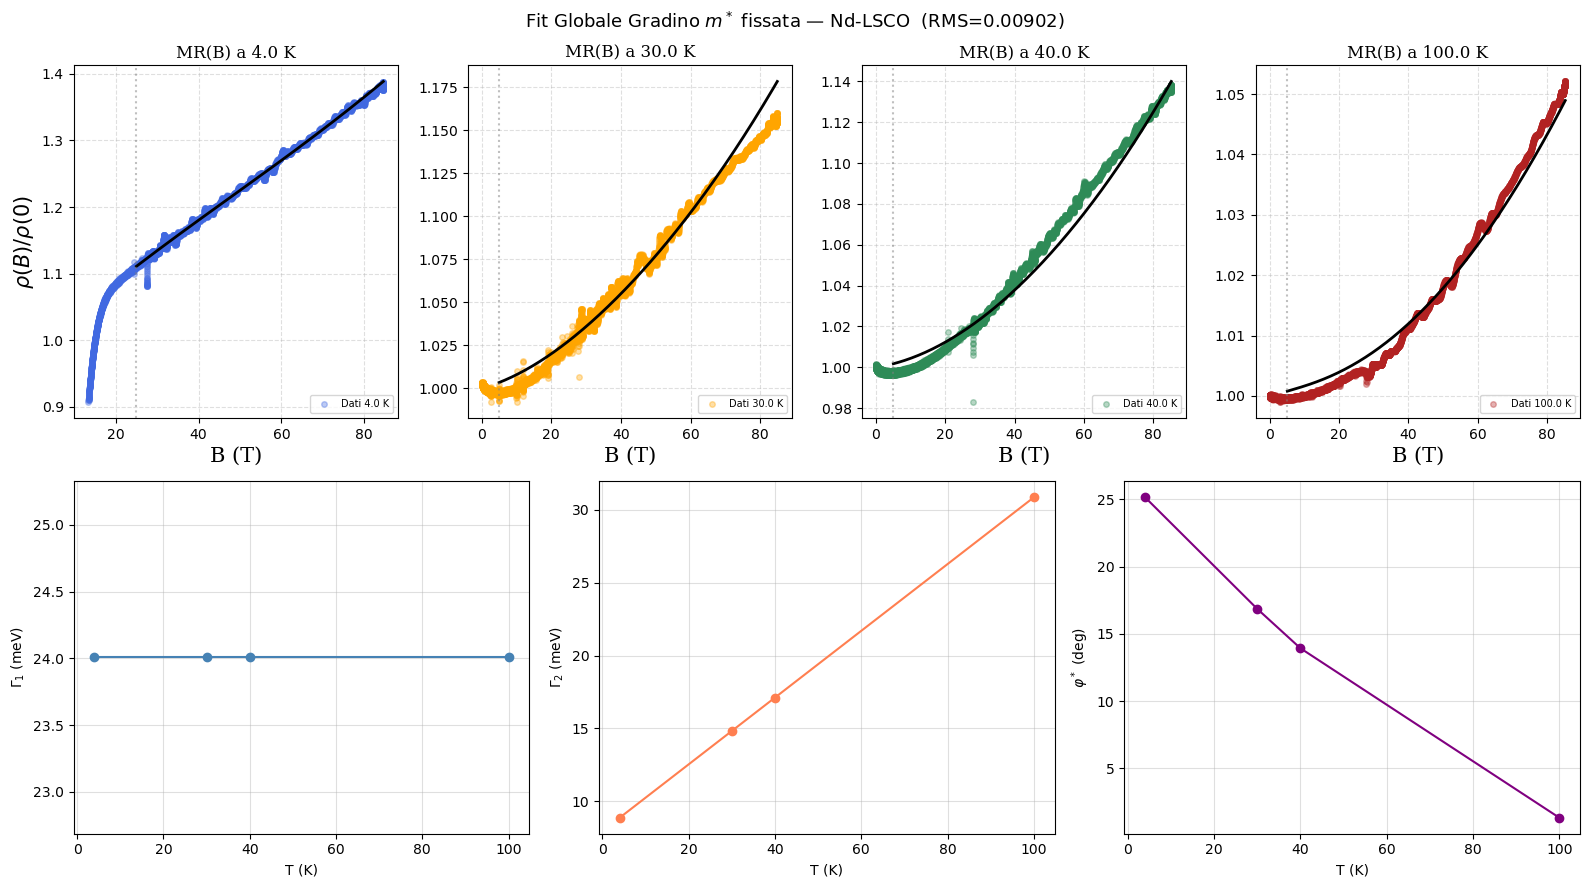

In [15]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 12, figure=fig)
axs_mr = [fig.add_subplot(gs[0, 0:3]), fig.add_subplot(gs[0, 3:6]),
          fig.add_subplot(gs[0, 6:9]), fig.add_subplot(gs[0, 9:12])]
ax_g1 = fig.add_subplot(gs[1, 0:4]); ax_g2 = fig.add_subplot(gs[1, 4:8]); ax_ph = fig.add_subplot(gs[1, 8:12])
for i, T in enumerate(T_LIST):
    ax = axs_mr[i]; B, R = DATA[T]; sel = B > B_MIN[T]
    g1_T = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2_T = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    ph_T = phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt)
    ax.plot(B, R, 'o', color=colors[T], markersize=4, alpha=0.35, label=f'Dati {T} K')
    B_pl = np.linspace(B[sel].min(), B.max(), 200)
    ax.plot(B_pl, 1.0 + cl.mr_step(B_pl, g1_T, g2_T, ph_T, m_star_opt), 'k-', lw=2)
    ax.axvline(B_MIN[T], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'MR(B) a {T} K', fontdict=font1, fontsize=12)
    ax.set_xlabel('B (T)', fontdict=font2)
    if i == 0:
        ax.set_ylabel(r'$\rho(B)/\rho(0)$', fontdict=font2)
    ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.4)
T_pl = np.array(T_LIST)
g1_pl = [eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1']) for T in T_pl]
g2_pl = [eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2']) for T in T_pl]
ph_pl = [np.degrees(phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt)) for T in T_pl]
ax_g1.plot(T_pl, g1_pl, 'o-', color='steelblue'); ax_g1.set_ylabel(r'$\Gamma_1$ (meV)'); ax_g1.grid(alpha=0.4)
ax_g2.plot(T_pl, g2_pl, 'o-', color='coral');     ax_g2.set_ylabel(r'$\Gamma_2$ (meV)'); ax_g2.grid(alpha=0.4)
ax_ph.plot(T_pl, ph_pl, 'o-', color='purple');    ax_ph.set_ylabel(r'$\varphi^*$ (deg)'); ax_ph.grid(alpha=0.4)
for ax in [ax_g1, ax_g2, ax_ph]: ax.set_xlabel('T (K)')
fig.suptitle(f'Fit Globale Gradino $m^*$ fissata — Nd-LSCO  (RMS={rms_step:.5f})', fontsize=13)
plt.tight_layout(); plt.show()

In [16]:
rows = []
for T in T_LIST:
    g1 = eval_T_dep(T, a1_opt, c1_opt, T_DEP['G1'])
    g2 = eval_T_dep(T, a2_opt, c2_opt, T_DEP['G2'])
    ph = np.degrees(phi_tanh(T, phi0_opt, dphi_opt, T_phi_opt))
    rows.append(f'| {T:g} | {g1:.3f} | {g2:.3f} | {ph:.2f} | {m_star_opt:.5f} |')
display(Markdown(
    '**Tabella — fit globale gradino $m^*$ fissata (Nd-LSCO)**\n\n'
    '| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\\varphi^*$ (deg) | $m^*/m_e$ |\n'
    '|---:|---:|---:|---:|---:|\n' + '\n'.join(rows)
))

**Tabella — fit globale gradino $m^*$ fissata (Nd-LSCO)**

| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\varphi^*$ (deg) | $m^*/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 24.007 | 8.867 | 25.16 | 1.48784 |
| 30 | 24.007 | 14.824 | 16.86 | 1.48784 |
| 40 | 24.007 | 17.116 | 13.94 | 1.48784 |
| 100 | 24.007 | 30.863 | 1.34 | 1.48784 |